In [1]:
import json

class Battle:
    def __init__(self,file_name):
        with open("replays/gen9-randombattle/" + file_name,"r") as battle_json:
            data = json.load(battle_json)
        self.log = data["log"]
        self.player_names = [data["players"][0],data["players"][1]]
        self.old_player_ratings = {} # a dictionary where the keys are the player usernames and the values are the player ratings at the start of the match
        self.new_player_ratings = {} # a dictionary where the keys are the player usernames and the values are the player ratings after the end of the match
        self.winner = ""
        self.loser = ""
        self.lead_pokemon = {self.player_names[0] : "", self.player_names[1] : ""} # dictionary where keys are player usernames and values are the first pokemon each player sent onto the field
        self.teams = {self.player_names[0] : set(), self.player_names[1]: set()} # a dictionary where the keys are player usernames and the values are sets containing the pokemon names
        self.time_list = [] # for keeping track of all move times, gets thrown away now.  Could be used to check for time-out forfeits?
        self.start_time = 0
        self.end_time = 0
        self.rated = (data["rating"] != None)
        self.log_parser(self.log)

    def __repr__(self):
        to_return = ""
        if self.rated:
            to_return += f"This was a battle between {self.player_names[0]} (pre-match rating {self.old_player_ratings[self.player_names[0]]}) and {self.player_names[1]} (pre-match rating {self.old_player_ratings[self.player_names[1]]}).\n"
        else:
            to_return += f"This was a battle between {self.player_names[0]} and {self.player_names[1]}.\n"
        for index in range(2):
            to_return += f"{self.player_names[index]}'s team was {self.teams[self.player_names[index]]} and their lead pokemon was {self.lead_pokemon[self.player_names[index]]}.\n"
        to_return += f"{self.winner} won!\n"
        if self.rated:
            to_return += f"{self.winner}'s rating increased to {self.new_player_ratings[self.winner]}.\n"
            to_return += f"{self.loser}'s rating fell to {self.new_player_ratings[self.loser]}."
        else:
            to_return += "This was an unrated match, so no one's rating changed."
        return to_return

    def log_parser(self,log):
        # This loop generates battle information by searching for *all* instances of "|t:|", "|switch|", "|win|", and " for winning)"
        # In particular, it sets the Battle object's new_player_ratings, winner, loser, teams, time_list, and rated attributes.
        for i in range(len(log)):
            # generates time list
            if log.startswith("|t:|",i):
                j = i + 4
                time_string = ""
                while log[j] != "\n":
                    time_string += log[j]
                    j += 1
                self.time_list.append(int(time_string))
            # generate team list
            if log.startswith("|switch|",i):
                pokemon_name = ""
                # Skip to the third pipe in the line.  This is where the species (including forme) is.
                pipe_counter = 0
                j = i
                while pipe_counter < 3:
                    if log[j] == "|":
                        pipe_counter += 1
                    j += 1
                # Now j is the first index after the third pipe in the line
                while log[j] != ",":
                    pokemon_name += log[j]
                    j += 1
                if log.startswith("p1a",i+8):
                    player_name = self.player_names[0]
                else:
                    player_name = self.player_names[1]
                self.teams[player_name].add(pokemon_name)
                if self.lead_pokemon[player_name] == "": # identifies  
                    self.lead_pokemon[player_name] = pokemon_name
            # identifies winner and loser
            if log.startswith("|win|",i):
                j = i + 5
                while log[j] != "\n":
                    self.winner += log[j]
                    j += 1
                winner_index = self.player_names.index(self.winner)
                self.loser = self.player_names[1-winner_index]
            if self.rated:
                for player_index in range(2):
                    if log.startswith(f"{self.player_names[player_index]}'s rating: ",i):
                        j = len(self.player_names[player_index]) + 11
                        old_score_string = ""
                        while log[i + j] != " ":
                            old_score_string += log[i+j]
                            j += 1
                        self.old_player_ratings[self.player_names[player_index]] = int(old_score_string)
                        self.new_player_ratings[self.player_names[player_index]] = int(log[i + j + 16:i + j + 16 + len(old_score_string)])
        # We separate start and end time for ease of access
        self.start_time = self.time_list[0]
        self.end_time = self.time_list[-1]

In [10]:
from pathlib import Path

In [45]:
import pandas as pd
import numpy as np

In [ ]:
log_dir = Path("gen9-randombattle")

rows = []

for file in log_dir.iterdir():
    if file.is_file():
        battle = Battle("../../gen9-randombattle/" + file.name)   

        p1 = battle.player_names[0]
        p2 = battle.player_names[1]

        rows.append({
            "battle_id": file.stem,

            "p1": p1,
            "p2": p2,

            "p1_team": sorted(list(battle.teams[p1])),
            "p2_team": sorted(list(battle.teams[p2])),

            "p1_lead": battle.lead_pokemon[p1],
            "p2_lead": battle.lead_pokemon[p2],

            "winner": battle.winner,
            "loser": battle.loser,
            "p1_win": battle.winner == p1,

            "rated": battle.rated,
            "p1_old_rating": battle.old_player_ratings.get(p1),
            "p2_old_rating": battle.old_player_ratings.get(p2),
            "p1_new_rating": battle.new_player_ratings.get(p1),
            "p2_new_rating": battle.new_player_ratings.get(p2),

            "start_time": battle.start_time,
            "end_time": battle.end_time,
            "duration": battle.end_time - battle.start_time,
        })

matches = pd.DataFrame(rows)


,battle_id,p1,p2,p1_team,p2_team,p1_lead,p2_lead,winner,loser,p1_win,rated,p1_old_rating,p2_old_rating,p1_new_rating,p2_new_rating,start_time,end_time,duration
0,gen9randombattle-2631360263,LaxMD,N.TdaRajada,"[Delphox, Indeedee-F, Skarmory, Tauros-Paldea-...","[Lokix, Mandibuzz, Mienshao, Snorlax, Torterra...",Delphox,Wigglytuff,N.TdaRajada,LaxMD,False,True,1789.0,1837.0,1772.0,1854.0,1781375540,1781376361,821
1,gen9randombattle-2631363920,kaisarian,Flamesenpai557,"[Ambipom, Breloom, Brute Bonnet, Mimikyu, Over...","[Arceus-Ghost, Breloom, Dugtrio-Alola, Gurdurr...",Mimikyu,Kilowattrel,kaisarian,Flamesenpai557,True,False,NaN,NaN,NaN,NaN,1781375954,1781376754,800
2,gen9randombattle-2631365384,rgrgreger,Ismusicalschool,"[Donphan, Electrode-Hisui, Flareon, Primarina,...","[Hippowdon, Houndoom, Iron Treads, Lugia, Luvd...",Electrode-Hisui,Iron Treads,rgrgreger,Ismusicalschool,True,True,1895.0,1946.0,1918.0,1923.0,1781376109,1781376433,324
3,gen9randombattle-2631366366,DustyHey1,UncleKrack,"[Gogoat, Iron Hands, Jumpluff, Lunala, Mudsdal...","[Dragalge, Fezandipiti, Gumshoos, Hydrapple, R...",Iron Hands,Fezandipiti,UncleKrack,DustyHey1,False,True,1506.0,1490.0,1485.0,1511.0,1781376225,1781376629,404
4,gen9randombattle-2631366401,RocketBC,toonnix,"[Arbok, Infernape, Magearna, Sceptile, Sylveon...","[Exeggutor-Alola, Komala, Tornadus, Victreebel...",Magearna,Victreebel,toonnix,RocketBC,False,True,1188.0,1195.0,1164.0,1219.0,1781376229,1781376612,383


In [15]:
matches.head(10)

,battle_id,p1,p2,p1_team,p2_team,p1_lead,p2_lead,winner,loser,p1_win,rated,p1_old_rating,p2_old_rating,p1_new_rating,p2_new_rating,start_time,end_time,duration
0,gen9randombattle-2631360263,LaxMD,N.TdaRajada,"[Delphox, Indeedee-F, Skarmory, Tauros-Paldea-...","[Lokix, Mandibuzz, Mienshao, Snorlax, Torterra...",Delphox,Wigglytuff,N.TdaRajada,LaxMD,False,True,1789.0,1837.0,1772.0,1854.0,1781375540,1781376361,821
1,gen9randombattle-2631363920,kaisarian,Flamesenpai557,"[Ambipom, Breloom, Brute Bonnet, Mimikyu, Over...","[Arceus-Ghost, Breloom, Dugtrio-Alola, Gurdurr...",Mimikyu,Kilowattrel,kaisarian,Flamesenpai557,True,False,NaN,NaN,NaN,NaN,1781375954,1781376754,800
2,gen9randombattle-2631365384,rgrgreger,Ismusicalschool,"[Donphan, Electrode-Hisui, Flareon, Primarina,...","[Hippowdon, Houndoom, Iron Treads, Lugia, Luvd...",Electrode-Hisui,Iron Treads,rgrgreger,Ismusicalschool,True,True,1895.0,1946.0,1918.0,1923.0,1781376109,1781376433,324
3,gen9randombattle-2631366366,DustyHey1,UncleKrack,"[Gogoat, Iron Hands, Jumpluff, Lunala, Mudsdal...","[Dragalge, Fezandipiti, Gumshoos, Hydrapple, R...",Iron Hands,Fezandipiti,UncleKrack,DustyHey1,False,True,1506.0,1490.0,1485.0,1511.0,1781376225,1781376629,404
4,gen9randombattle-2631366401,RocketBC,toonnix,"[Arbok, Infernape, Magearna, Sceptile, Sylveon...","[Exeggutor-Alola, Komala, Tornadus, Victreebel...",Magearna,Victreebel,toonnix,RocketBC,False,True,1188.0,1195.0,1164.0,1219.0,1781376229,1781376612,383
5,gen9randombattle-2631366548,Vincent553,Doc Peppa,"[Blaziken, Giratina, Mamoswine, Porygon-Z, Qua...","[Garchomp, Haxorus, Lilligant, Minun, Quagsire...",Giratina,Lilligant,Doc Peppa,Vincent553,False,True,1591.0,1600.0,1572.0,1619.0,1781376245,1781376595,350
6,gen9randombattle-2631366692,a1iscool4718,AshJogos43,"[Bastiodon, Komala, Munkidori, Scizor, Sunflor...","[Basculegion, Bellibolt, Klawf, Lunala, Slowbr...",Scizor,Weavile,AshJogos43,a1iscool4718,False,True,1530.0,1491.0,1508.0,1513.0,1781376261,1781376466,205
7,gen9randombattle-2631366781,Pode Isso Armald0,EVOL7N,"[Arceus-Water, Bombirdier, Lunala, Mimikyu, Wh...","[Heracross, Iron Jugulis, Noctowl, Slaking]",Lunala,Heracross,EVOL7N,Pode Isso Armald0,False,True,1674.0,1636.0,1652.0,1658.0,1781376271,1781376661,390
8,gen9randombattle-2631368445,Goundas05,bluffmepls,"[Alomomola, Coalossal, Drednaw, Flareon, Hypno...","[Blissey, Pawmot, Tropius, Wugtrio]",Hypno,Pawmot,bluffmepls,Goundas05,False,False,NaN,NaN,NaN,NaN,1781376456,1781376614,158
9,gen9randombattle-2631368578,Seshuyong,mv_sv3tl4na,"[Basculegion, Bellibolt, Deoxys-Speed, Exeggut...","[Ariados, Dedenne, Lapras, Pawmot, Primarina, ...",Bellibolt,Pyroar,Seshuyong,mv_sv3tl4na,True,True,1000.0,1046.0,1045.0,1027.0,1781376471,1781376799,328


In [16]:
matches.shape

(4798, 18)

In [17]:
matches.info()

<class 'pandas.DataFrame'>
RangeIndex: 4798 entries, 0 to 4797
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battle_id      4798 non-null   str    
 1   p1             4798 non-null   str    
 2   p2             4798 non-null   str    
 3   p1_team        4798 non-null   object 
 4   p2_team        4798 non-null   object 
 5   p1_lead        4798 non-null   str    
 6   p2_lead        4798 non-null   str    
 7   winner         4798 non-null   str    
 8   loser          4798 non-null   str    
 9   p1_win         4798 non-null   bool   
 10  rated          4798 non-null   bool   
 11  p1_old_rating  1445 non-null   float64
 12  p2_old_rating  1450 non-null   float64
 13  p1_new_rating  1445 non-null   float64
 14  p2_new_rating  1450 non-null   float64
 15  start_time     4798 non-null   int64  
 16  end_time       4798 non-null   int64  
 17  duration       4798 non-null   int64  
dtypes: bool(2), float64

In [18]:
matches["rated"].value_counts()

rated
False    3339
True     1459
Name: count, dtype: int64

In [20]:
rated_missing = matches[
    (matches["rated"]) & (
        matches["p1_old_rating"].isna() |
        matches["p2_old_rating"].isna() |
        matches["p1_new_rating"].isna() |
        matches["p2_new_rating"].isna()
    )
]

rated_missing.shape

(23, 18)

We have full rating data for 1445 matches, and the missing rating data almost matches the unrated matches.

In [22]:
print("Number of battles:", len(matches))
print("Unique battle IDs:", matches["battle_id"].nunique())
print("p1 win rate:", matches["p1_win"].mean())

Number of battles: 4798
Unique battle IDs: 4798
p1 win rate: 0.47894956231763236


Player 1 wins 47.9% of the matches. 

In [24]:
matches["p1_team_size"] = matches["p1_team"].apply(len)
matches["p2_team_size"] = matches["p2_team"].apply(len)

team_size_table = pd.crosstab(
    matches["p1_team_size"],
    matches["p2_team_size"],
    rownames=["p1_team_size"],
    colnames=["p2_team_size"],
    margins=True
)

display(team_size_table)

p2_team_size,1,2,3,4,5,6,7,8,All
p1_team_size,,,,,,,,,
1,81,28,27,8,4,6,0,0,154
2,27,47,38,32,15,28,1,0,188
3,12,44,65,63,43,38,0,0,265
4,12,29,67,94,109,167,2,1,481
5,4,13,55,119,192,518,13,0,914
6,9,19,41,219,572,1825,45,0,2730
7,0,0,0,3,17,44,1,0,65
8,0,0,0,0,0,1,0,0,1
All,145,180,293,538,952,2627,62,1,4798


In [29]:
large_team_matches = matches[
    (matches["p1_team_size"] > 6) | 
    (matches["p2_team_size"] > 6)
]

In [33]:
for i in range(5):
    row = large_team_matches.iloc[i]
    print("p1_team:", row["p1_team"])
    print("p2_team:", row["p2_team"])

p1_team: ['Arbok', 'Phione', 'Salamence', 'Sinistcha-Masterpiece', 'Terapagos', 'Terapagos-Terastal', 'Zacian-Crowned']
p2_team: ['Arcanine-Hisui', 'Azumarill', 'Gholdengo', 'Gumshoos', 'Koraidon', 'Regidrago']
p1_team: ['Cramorant', 'Fezandipiti', 'Furret', 'Indeedee-F']
p2_team: ['Banette', 'Gardevoir', 'Heracross', 'Hippowdon', 'Mimikyu', 'Mimikyu-Busted', 'Volcanion']
p1_team: ['Darkrai', 'Golem-Alola', 'Iron Leaves', 'Ogerpon-Cornerstone', 'Ogerpon-Cornerstone-Tera', 'Tentacruel', 'Vespiquen']
p2_team: ['Bisharp', 'Forretress', 'Mightyena', 'Minior', 'Ogerpon-Wellspring', 'Salazzle']
p1_team: ['Charizard', 'Donphan', 'Glastrier', 'Greedent', 'Plusle', 'Whimsicott']
p2_team: ['Forretress', 'Hawlucha', 'Jolteon', 'Krookodile', 'Luvdisc', 'Palafin', 'Palafin-Hero']
p1_team: ['Drifblim', 'Grumpig', 'Palafin', 'Palafin-Hero', 'Phione', 'Rhyperior', 'Torkoal']
p2_team: ['Donphan', 'Krookodile', 'Raikou', 'Slowbro-Galar', 'Suicune']


**The parsed team size is not always controlled by 6**

For a Pokemon with form change during the battle, the battle-class considers them as different Pokemons. While this is obvious in teams with size > 6, this could remain undetected by the team size method if the number of Pokemons does not go beyond 6.


In [34]:
matches["p1_lead_in_team"] = matches.apply(
    lambda row: row["p1_lead"] in row["p1_team"],
    axis=1
)

matches["p2_lead_in_team"] = matches.apply(
    lambda row: row["p2_lead"] in row["p2_team"],
    axis=1
)

lead_check_table = pd.crosstab(
    matches["p1_lead_in_team"],
    matches["p2_lead_in_team"],
    rownames=["p1_lead_in_team"],
    colnames=["p2_lead_in_team"],
    margins=True
)

lead_check_table

p2_lead_in_team,True,All
p1_lead_in_team,,
True,4798,4798
All,4798,4798


In [36]:
pokedex = pd.read_csv("Pokedex_cleaned.csv", encoding="latin1")

pokedex.head()

,#,Name,Primary Type,Secondary Type,Total,HP,Attack,Defense,Sp.Atk,Sp.Def,Speed,Variant
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,NaN
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,NaN
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,NaN
3,3,Venusaur,Grass,Poison,625,80,100,123,122,120,80,NaN
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,NaN


In [37]:
pokedex.info()

<class 'pandas.DataFrame'>
RangeIndex: 1173 entries, 0 to 1172
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   #               1173 non-null   int64
 1   Name            1173 non-null   str  
 2   Primary Type    1173 non-null   str  
 3   Secondary Type  633 non-null    str  
 4   Total           1173 non-null   int64
 5   HP              1173 non-null   int64
 6   Attack          1173 non-null   int64
 7   Defense         1173 non-null   int64
 8   Sp.Atk          1173 non-null   int64
 9   Sp.Def          1173 non-null   int64
 10  Speed           1173 non-null   int64
 11  Variant         190 non-null    str  
dtypes: int64(8), str(4)
memory usage: 130.3 KB


In [38]:
#Temporarily replacing variants to match the names such as "Charizard-Mega-X" 
pokedex["Variant"] = pokedex["Variant"].fillna("").astype(str).str.strip()
pokedex["Name"] = pokedex["Name"].astype(str).str.strip()

def make_pokedex_key(row):
    name = row["Name"]
    variant = row["Variant"]

    if variant == "":
        return name
    else:
        variant_key = variant.replace(" ", "-")
        return f"{name}-{variant_key}"

pokedex["pokemon_key"] = pokedex.apply(make_pokedex_key, axis=1)

pokedex[["Name", "Variant", "pokemon_key"]].head(20)

,Name,Variant,pokemon_key
0,Bulbasaur,,Bulbasaur
1,Ivysaur,,Ivysaur
2,Venusaur,,Venusaur
3,Venusaur,,Venusaur
4,Charmander,,Charmander
5,Charmeleon,,Charmeleon
6,Charizard,Mega X,Charizard-Mega-X
7,Charizard,Mega Y,Charizard-Mega-Y
8,Charizard,,Charizard
9,Squirtle,,Squirtle


In [39]:
pokedex["pokemon_key"].is_unique

False

In [40]:
duplicate_keys = pokedex[pokedex["pokemon_key"].duplicated(keep=False)]

duplicate_keys.sort_values("pokemon_key")[[
    "pokemon_key", "Name", "Variant", "Total",
    "HP", "Attack", "Defense", "Sp.Atk", "Sp.Def", "Speed"
]]

,pokemon_key,Name,Variant,Total,HP,Attack,Defense,Sp.Atk,Sp.Def,Speed
1147,Kingambit,Kingambit,,550,100,135,120,60,85,50
1148,Kingambit,Kingambit,,550,100,135,120,60,85,50
801,Meowstic,Meowstic,,466,74,48,76,83,81,104
802,Meowstic,Meowstic,,466,74,48,76,83,81,104
40,Nidoran?,Nidoran?,,275,55,47,52,40,40,41
43,Nidoran?,Nidoran?,,273,46,57,40,40,40,50
580,Rotom,Rotom,,440,50,50,77,95,77,91
581,Rotom,Rotom,,440,50,50,77,95,77,91
916,Type:,Type:,,534,95,95,95,95,95,59
917,Type:,Type:,,534,95,95,95,95,95,59


I used Mohammed's Cleaned Pokedex here. For variants such as mega X Charizard I just used "Charizard-Mega-X" to match the name in the battle log. It just seems that there are a few duplicates need to be fixed.

In [41]:
key_counts = pokedex["pokemon_key"].value_counts()

unique_keys = set(key_counts[key_counts == 1].index)
duplicate_keys = set(key_counts[key_counts > 1].index)

pokedex_unique = pokedex[pokedex["pokemon_key"].isin(unique_keys)].set_index("pokemon_key")

In [42]:
stat_cols = [
    "Total", "HP", "Attack", "Defense",
    "Sp.Atk", "Sp.Def", "Speed"
]

In [43]:
def team_stat_summary(team, pokedex_table):
    matched_stats = []
    ambiguous_count = 0
    unmatched_count = 0

    for mon in team:
        if mon in pokedex_table.index:
            matched_stats.append(pokedex_table.loc[mon, stat_cols])
        elif mon in duplicate_keys:
            ambiguous_count += 1
        else:
            unmatched_count += 1

    if len(matched_stats) == 0:
        output = {
            "team_size": len(team),
            "matched_count": 0,
            "ambiguous_count": ambiguous_count,
            "unmatched_count": unmatched_count,
        }

        for stat in stat_cols:
            output[f"avg_{stat}"] = np.nan
            output[f"max_{stat}"] = np.nan
            output[f"min_{stat}"] = np.nan

        return pd.Series(output)

    stats_df = pd.DataFrame(matched_stats).astype(float)

    output = {
        "team_size": len(team),
        "matched_count": len(matched_stats),
        "ambiguous_count": ambiguous_count,
        "unmatched_count": unmatched_count,
    }

    for stat in stat_cols:
        output[f"avg_{stat}"] = stats_df[stat].mean()
        output[f"max_{stat}"] = stats_df[stat].max()
        output[f"min_{stat}"] = stats_df[stat].min()

    return pd.Series(output)

In [46]:
p1_team_stats = matches["p1_team"].apply(
    lambda team: team_stat_summary(team, pokedex_unique)
).add_prefix("p1_")

p2_team_stats = matches["p2_team"].apply(
    lambda team: team_stat_summary(team, pokedex_unique)
).add_prefix("p2_")

In [47]:
team_stats_df = pd.concat(
    [
        matches[["battle_id", "p1_win"]],
        p1_team_stats,
        p2_team_stats
    ],
    axis=1
)

In [48]:
team_stats_df.head(20)

,battle_id,p1_win,p1_team_size,p1_matched_count,p1_ambiguous_count,p1_unmatched_count,p1_avg_Total,p1_max_Total,p1_min_Total,p1_avg_HP,...,p2_min_Defense,p2_avg_Sp.Atk,p2_max_Sp.Atk,p2_min_Sp.Atk,p2_avg_Sp.Def,p2_max_Sp.Def,p2_min_Sp.Def,p2_avg_Speed,p2_max_Speed,p2_min_Speed
0,gen9randombattle-2631360263,False,6.0,4.0,0.0,2.0,478.500000,534.0,425.0,63.750000,...,45.0,71.166667,95.0,52.0,75.833333,110.0,50.0,68.000000,105.0,30.0
1,gen9randombattle-2631363920,True,6.0,6.0,0.0,0.0,488.833333,570.0,435.0,72.333333,...,60.0,75.000000,105.0,40.0,58.750000,65.0,50.0,83.750000,125.0,40.0
2,gen9randombattle-2631365384,True,5.0,4.0,0.0,1.0,491.250000,530.0,410.0,76.250000,...,50.0,80.000000,110.0,40.0,91.833333,154.0,65.0,80.833333,110.0,30.0
3,gen9randombattle-2631366366,False,6.0,6.0,0.0,0.0,568.500000,680.0,460.0,116.500000,...,60.0,83.000000,135.0,45.0,83.250000,123.0,45.0,57.250000,100.0,40.0
4,gen9randombattle-2631366401,False,6.0,6.0,0.0,0.0,525.333333,600.0,448.0,77.833333,...,50.0,75.000000,100.0,50.0,78.333333,95.0,70.0,85.000000,120.0,65.0
5,gen9randombattle-2631366548,False,6.0,4.0,0.0,2.0,541.250000,670.0,430.0,102.500000,...,50.0,74.000000,110.0,54.0,74.500000,85.0,65.0,84.833333,102.0,35.0
6,gen9randombattle-2631366692,False,6.0,5.0,0.0,1.0,479.800000,500.0,425.0,69.600000,...,65.0,84.000000,137.0,35.0,82.000000,107.0,55.0,74.400000,125.0,30.0
7,gen9randombattle-2631366781,False,5.0,4.0,0.0,1.0,527.250000,680.0,468.0,93.000000,...,50.0,85.750000,122.0,40.0,84.000000,96.0,65.0,90.750000,108.0,70.0
8,gen9randombattle-2631368445,False,6.0,6.0,0.0,0.0,487.833333,525.0,454.0,97.500000,...,10.0,66.750000,75.0,50.0,88.000000,135.0,60.0,82.750000,120.0,51.0
9,gen9randombattle-2631368578,True,6.0,3.0,0.0,3.0,491.666667,495.0,490.0,95.666667,...,57.0,88.500000,126.0,60.0,79.000000,116.0,60.0,78.666667,106.0,40.0


In [49]:
team_stats_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4798 entries, 0 to 4797
Data columns (total 52 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   battle_id           4798 non-null   str    
 1   p1_win              4798 non-null   bool   
 2   p1_team_size        4798 non-null   float64
 3   p1_matched_count    4798 non-null   float64
 4   p1_ambiguous_count  4798 non-null   float64
 5   p1_unmatched_count  4798 non-null   float64
 6   p1_avg_Total        4760 non-null   float64
 7   p1_max_Total        4760 non-null   float64
 8   p1_min_Total        4760 non-null   float64
 9   p1_avg_HP           4760 non-null   float64
 10  p1_max_HP           4760 non-null   float64
 11  p1_min_HP           4760 non-null   float64
 12  p1_avg_Attack       4760 non-null   float64
 13  p1_max_Attack       4760 non-null   float64
 14  p1_min_Attack       4760 non-null   float64
 15  p1_avg_Defense      4760 non-null   float64
 16  p1_max_Defense   

In [50]:
p1_missing_stats = team_stats_df[team_stats_df["p1_avg_Total"].isna()]

p1_missing_stats[[
    "battle_id",
    "p1_team_size",
    "p1_matched_count",
    "p1_ambiguous_count",
    "p1_unmatched_count"
]].head(20)

,battle_id,p1_team_size,p1_matched_count,p1_ambiguous_count,p1_unmatched_count
45,gen9randombattle-2631372891,2.0,0.0,0.0,2.0
212,gen9randombattle-2631390612,2.0,0.0,0.0,2.0
444,gen9randombattle-2631422539,1.0,0.0,0.0,1.0
889,gen9randombattle-2631481412,3.0,0.0,0.0,3.0
898,gen9randombattle-2631482776,1.0,0.0,0.0,1.0
946,gen9randombattle-2631487840,2.0,0.0,0.0,2.0
947,gen9randombattle-2631487904,1.0,0.0,0.0,1.0
1006,gen9randombattle-2631494597,4.0,0.0,0.0,4.0
1077,gen9randombattle-2631504150,1.0,0.0,0.0,1.0
1096,gen9randombattle-2631506550,1.0,0.0,0.0,1.0


Some unmatched pokemons but fine.

In [51]:
import matplotlib.pyplot as plt

In [53]:
stats = ["HP", "Attack", "Defense", "Sp.Atk", "Sp.Def", "Speed", "Total"]

for stat in stats:
    team_stats_df[f"avg_{stat}_diff"] = (
        team_stats_df[f"p1_avg_{stat}"] - team_stats_df[f"p2_avg_{stat}"]
    )

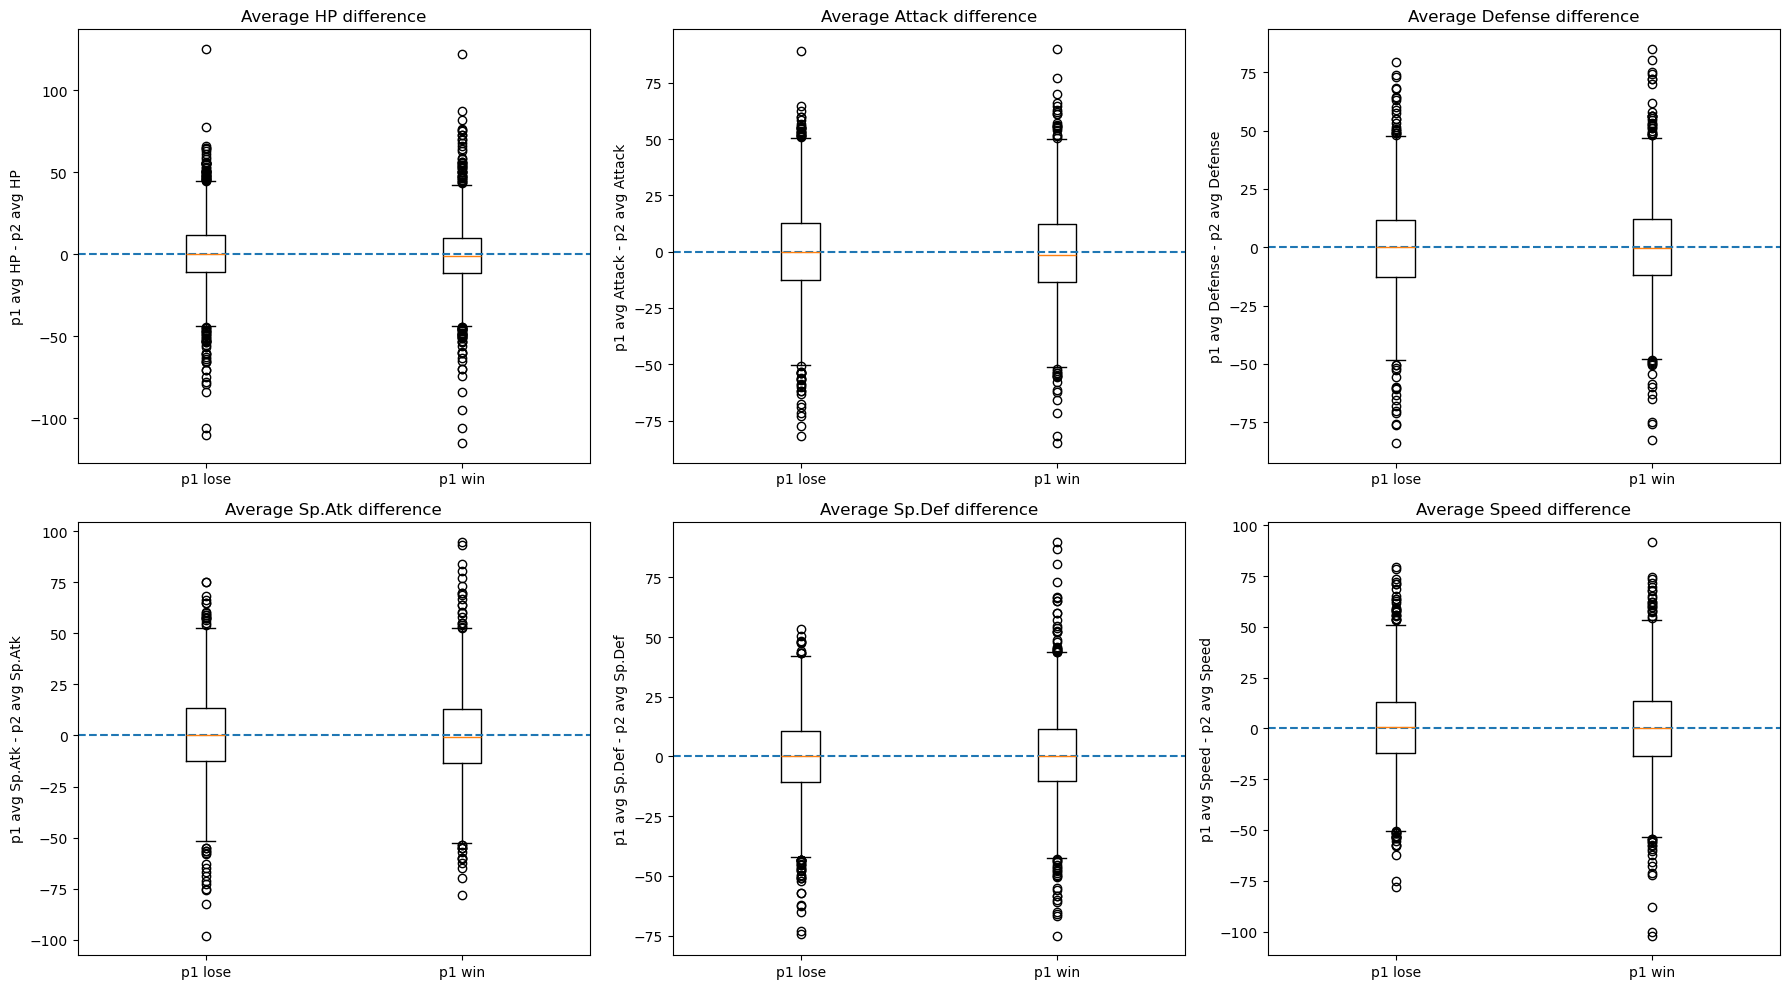

In [56]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

stats = ["HP", "Attack", "Defense", "Sp.Atk", "Sp.Def", "Speed"]

for ax, stat in zip(axes, stats):
    col = f"avg_{stat}_diff"

    plot_df = team_stats_df.dropna(subset=[col]).copy()

    win_values = plot_df.loc[plot_df["p1_win"], col]
    lose_values = plot_df.loc[~plot_df["p1_win"], col]

    ax.boxplot([lose_values, win_values], tick_labels=["p1 lose", "p1 win"])
    ax.axhline(0, linestyle="--")
    ax.set_title(f"Average {stat} difference")
    ax.set_ylabel(f"p1 avg {stat} - p2 avg {stat}")

plt.tight_layout()
plt.show()

We don't see an obvious pattern here, maybe because using the avg stats alone is too noisy. 

In [65]:
# Average combined stats
team_stats_df["p1_avg_offense"] = (
    team_stats_df["p1_avg_Attack"] + team_stats_df["p1_avg_Sp.Atk"]
) / 2

team_stats_df["p2_avg_offense"] = (
    team_stats_df["p2_avg_Attack"] + team_stats_df["p2_avg_Sp.Atk"]
) / 2

team_stats_df["p1_avg_bulk"] = (
    team_stats_df["p1_avg_HP"] +
    team_stats_df["p1_avg_Defense"] +
    team_stats_df["p1_avg_Sp.Def"]
) / 3

team_stats_df["p2_avg_bulk"] = (
    team_stats_df["p2_avg_HP"] +
    team_stats_df["p2_avg_Defense"] +
    team_stats_df["p2_avg_Sp.Def"]
) / 3

team_stats_df["p1_avg_physical"] = (
    team_stats_df["p1_avg_Attack"] + team_stats_df["p1_avg_Defense"]
) / 2

team_stats_df["p2_avg_physical"] = (
    team_stats_df["p2_avg_Attack"] + team_stats_df["p2_avg_Defense"]
) / 2

team_stats_df["p1_avg_special"] = (
    team_stats_df["p1_avg_Sp.Atk"] + team_stats_df["p1_avg_Sp.Def"]
) / 2

team_stats_df["p2_avg_special"] = (
    team_stats_df["p2_avg_Sp.Atk"] + team_stats_df["p2_avg_Sp.Def"]
) / 2

In [66]:
combined_stats = [
    "avg_Total",
    "avg_offense",
    "avg_bulk",
    "avg_physical",
    "avg_special",
    "avg_Speed"
]

for stat in combined_stats:
    team_stats_df[f"{stat}_diff"] = (
        team_stats_df[f"p1_{stat}"] - team_stats_df[f"p2_{stat}"]
    )

In [67]:
combined_diff_cols = [f"{stat}_diff" for stat in combined_stats]

corr_combined = (
    team_stats_df[combined_diff_cols + ["p1_win"]]
    .corr(numeric_only=True)["p1_win"]
    .sort_values(ascending=False)
)

corr_combined

p1_win               1.000000
avg_bulk_diff       -0.004932
avg_physical_diff   -0.006850
avg_special_diff    -0.008015
avg_Speed_diff      -0.013336
avg_Total_diff      -0.026873
avg_offense_diff    -0.030523
Name: p1_win, dtype: float64

**A bit weird due to this weak but negative correlation. Maybe because the levels in rand battles for Pokemons with higher base stats are usually lower?**